<a href="https://colab.research.google.com/github/e23046/Statistical-Learning-e23046/blob/main/Assignment%2007/Assignment__07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

## Answer

Throughout, we use two standard facts about the multivariate Gaussian distribution, which we will reuse repeatedly:

**Fact 1 (linear transformations of Gaussians are Gaussian).** If $v\sim\mathscr N(\mu,\Sigma)$ and $u = Lv+b$ for a fixed matrix $L$ and vector $b$, then $u$ is Gaussian, with $E[u]=L\mu+b$ and $\mathrm{Cov}(u)=L\Sigma L^T$. This follows directly from the characteristic function $\varphi_u(t)=E[e^{it^Tu}]=e^{it^Tb}\varphi_v(L^Tt)$, which is again of Gaussian form.

**Fact 2 (independent Gaussians are jointly Gaussian).** If $v_1\sim\mathscr N(\mu_1,\Sigma_1)$ and $v_2\sim\mathscr N(\mu_2,\Sigma_2)$ are independent, then $\begin{bmatrix}v_1\\v_2\end{bmatrix}$ is jointly Gaussian with mean $\begin{bmatrix}\mu_1\\\mu_2\end{bmatrix}$ and block-diagonal covariance $\mathrm{blkdiag}(\Sigma_1,\Sigma_2)$, because the joint density is the product of two Gaussian densities, which is itself a (degenerate or non-degenerate) Gaussian density in the stacked variable.

### Part 1 — Distribution of the predicted state $x_k^-$

By assumption $x_{k-1}^+\sim\mathscr N(m_{k-1},P_{k-1})$ and $w_{k-1}\sim\mathscr N(0,\Sigma_p)$, and the two are independent (the process noise is independent of the current state estimate). By **Fact 2**, $\begin{bmatrix}x_{k-1}^+\\w_{k-1}\end{bmatrix}$ is jointly Gaussian. Since

$$x_k^- = \begin{bmatrix}A_{k-1} & G_{k-1}\end{bmatrix}\begin{bmatrix}x_{k-1}^+\\w_{k-1}\end{bmatrix},$$

is a linear function of this jointly Gaussian vector, **Fact 1** guarantees $x_k^-$ is Gaussian. Its mean is

$$m_k^- = E[x_k^-] = A_{k-1}E[x_{k-1}^+] + G_{k-1}E[w_{k-1}] = A_{k-1}m_{k-1}.$$

For the covariance, write $\tilde x_{k-1}=x_{k-1}^+-m_{k-1}$, so $x_k^- - m_k^- = A_{k-1}\tilde x_{k-1} + G_{k-1}w_{k-1}$, and

\begin{align*}
P_k^- &= E\big[(x_k^--m_k^-)(x_k^--m_k^-)^T\big] \\
&= A_{k-1}E[\tilde x_{k-1}\tilde x_{k-1}^T]A_{k-1}^T + A_{k-1}E[\tilde x_{k-1}w_{k-1}^T]G_{k-1}^T \\
&\quad + G_{k-1}E[w_{k-1}\tilde x_{k-1}^T]A_{k-1}^T + G_{k-1}E[w_{k-1}w_{k-1}^T]G_{k-1}^T.
\end{align*}

Since $\tilde x_{k-1}$ and $w_{k-1}$ are independent and $E[w_{k-1}]=0$, the two cross-covariance terms are zero, leaving

$$\boxed{P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.}$$

### Part 2 — Distribution of the predicted measurement $y_k^-$

We are told $z_k\sim\mathscr N(0,\Sigma_m)$ is independent of $x_k^-$ (measurement noise is independent of the state). By Part 1, $x_k^-\sim\mathscr N(m_k^-,P_k^-)$, so by **Fact 2** the pair $(x_k^-,z_k)$ is jointly Gaussian, and

$$y_k^- = \begin{bmatrix}H_k & I\end{bmatrix}\begin{bmatrix}x_k^-\\z_k\end{bmatrix}$$

is, by **Fact 1**, Gaussian with mean

$$E[y_k^-] = H_kE[x_k^-] + E[z_k] = H_km_k^-,$$

and covariance (cross-terms vanish by independence, exactly as in Part 1)

$$\mathrm{Cov}(y_k^-) = H_kP_k^-H_k^T + \Sigma_m.$$

Hence $\boxed{y_k^- \sim \mathscr N(H_km_k^-,\ H_kP_k^-H_k^T+\Sigma_m).}$

### Part 3 — Joint distribution of $(x_k^-, y_k^-)$

Stack $x_k^-$ and $z_k$, which by **Fact 2** are jointly Gaussian (independent, with $x_k^-\sim\mathscr N(m_k^-,P_k^-)$ and $z_k\sim\mathscr N(0,\Sigma_m)$). The pair $(x_k^-,y_k^-)$ is an exact linear function of $(x_k^-,z_k)$:

$$\begin{bmatrix}x_k^-\\y_k^-\end{bmatrix} = \underbrace{\begin{bmatrix}I & 0\\ H_k & I\end{bmatrix}}_{\textstyle M}\begin{bmatrix}x_k^-\\z_k\end{bmatrix}.$$

By **Fact 1** this is jointly Gaussian, with mean $M\begin{bmatrix}m_k^-\\0\end{bmatrix}=\begin{bmatrix}m_k^-\\H_km_k^-\end{bmatrix}$, matching the claim. For the covariance, with $\Sigma \triangleq \mathrm{blkdiag}(P_k^-,\Sigma_m)$,

\begin{align*}
M\Sigma M^T
&= \begin{bmatrix}I & 0\\ H_k & I\end{bmatrix}\begin{bmatrix}P_k^- & 0\\ 0 & \Sigma_m\end{bmatrix}\begin{bmatrix}I & H_k^T\\ 0 & I\end{bmatrix} \\
&= \begin{bmatrix}P_k^- & 0\\ H_kP_k^- & \Sigma_m\end{bmatrix}\begin{bmatrix}I & H_k^T\\ 0 & I\end{bmatrix} \\
&= \begin{bmatrix}P_k^- & P_k^-H_k^T\\ H_kP_k^- & H_kP_k^-H_k^T+\Sigma_m\end{bmatrix},
\end{align*}

which is exactly the claimed joint covariance. Hence

$$\boxed{\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).}$$

### Part 4 — Conditional distribution (the update step)

We need the following standard result for jointly Gaussian vectors.

**Lemma (Gaussian conditioning).** If $\begin{bmatrix}u\\v\end{bmatrix}\sim\mathscr N\left(\begin{bmatrix}\mu_u\\\mu_v\end{bmatrix}, \begin{bmatrix}\Sigma_{uu}&\Sigma_{uv}\\ \Sigma_{vu}&\Sigma_{vv}\end{bmatrix}\right)$ with $\Sigma_{vv}$ invertible, then
$$u\mid v=v_0\ \sim\ \mathscr N\big(\mu_u+\Sigma_{uv}\Sigma_{vv}^{-1}(v_0-\mu_v),\ \ \Sigma_{uu}-\Sigma_{uv}\Sigma_{vv}^{-1}\Sigma_{vu}\big).$$

*Proof sketch:* define the residual $e \triangleq u-\mu_u-\Sigma_{uv}\Sigma_{vv}^{-1}(v-\mu_v)$, which is a linear combination of $u$ and $v$ and is therefore (by Fact 1) jointly Gaussian with $v$. A direct computation gives $\mathrm{Cov}(e,v)=\Sigma_{uv}-\Sigma_{uv}\Sigma_{vv}^{-1}\Sigma_{vv}=0$. Since $e$ and $v$ are jointly Gaussian and uncorrelated, they are **independent**. Hence conditioning on $v=v_0$ does not change the distribution of $e$, so $e\mid v=v_0 \sim \mathscr N(0,\ \mathrm{Cov}(e))$, where $\mathrm{Cov}(e)=\Sigma_{uu}-\Sigma_{uv}\Sigma_{vv}^{-1}\Sigma_{vu}$ (expand and use $\mathrm{Cov}(e,v)=0$). Writing $u = \mu_u+\Sigma_{uv}\Sigma_{vv}^{-1}(v-\mu_v) + e$ and substituting $v=v_0$ gives the stated conditional mean and covariance. $\blacksquare$

**Applying the lemma** with $u=x_k^-$, $v=y_k^-$, and the joint moments from Part 3:
$$\mu_u = m_k^-,\quad \mu_v = H_km_k^-,\quad \Sigma_{uu}=P_k^-,\quad \Sigma_{uv}=P_k^-H_k^T,\quad \Sigma_{vv}=H_kP_k^-H_k^T+\Sigma_m,$$

we get, defining $K_k \triangleq P_k^-H_k^T(H_kP_k^-H_k^T+\Sigma_m)^{-1} = \Sigma_{uv}\Sigma_{vv}^{-1}$,

$$m_k = m_k^- + K_k\big(y_k^{\mathrm{obs}} - H_km_k^-\big),$$

$$P_k = P_k^- - K_kH_kP_k^- = (I-K_kH_k)P_k^-.$$

Since the lemma also guarantees the conditional law is Gaussian, we conclude

$$\boxed{x_k^+ \triangleq (x_k^-\mid y_k^- = y_k^{\mathrm{obs}}) \sim \mathscr N(m_k, P_k),}$$

with $K_k$, $m_k$, $P_k$ exactly as given in the problem statement. This is precisely the **Kalman filter measurement-update (correction) step**.

### Part 5 — $\mathbb E[x_k^-\mid y_k^-=y_k^{\mathrm{obs}}]$ and $\mathrm{Var}(x_k^-\mid y_k^-=y_k^{\mathrm{obs}})$

By definition in Part 4, $x_k^+$ **is** the random variable $x_k^-$ conditioned on the event $y_k^-=y_k^{\mathrm{obs}}$, i.e. $x_k^+ \triangleq (x_k^-\mid y_k^-=y_k^{\mathrm{obs}})$. Since we have just shown $x_k^+\sim\mathscr N(m_k,P_k)$, the conditional mean and covariance of $x_k^-$ itself (not of some other variable) are immediately read off from this same result:

$$\boxed{\mathbb E[x_k^-\mid y_k^-=y_k^{\mathrm{obs}}] = m_k = m_k^- + K_k\big(y_k^{\mathrm{obs}}-H_km_k^-\big),}$$

$$\boxed{\mathrm{Var}(x_k^-\mid y_k^-=y_k^{\mathrm{obs}}) = P_k = (I-K_kH_k)P_k^-.}$$

In other words, Parts 4 and 5 are two phrasings of the *same* Bayesian update: the filtered state $x_k^+$ is, by construction, nothing other than the predicted state $x_k^-$ updated by conditioning on the realized measurement — there is no new computation required beyond Part 4.

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

## Answer (Parts 1–4: analytical results)

The scalar model is the $1\times1$ special case of the general linear-Gaussian model analyzed in the previous question, with

$$A_{k-1}=a,\quad G_{k-1}=1,\quad \Sigma_p=q,\quad H_k=h,\quad \Sigma_m=r.$$

Every result below is therefore a direct specialization of the boxed results proved above (all matrices are now scalars, so transposes and matrix inverses become ordinary scalar operations).

### Part 1 — Prediction step

Substituting $A_{k-1}=a$, $G_{k-1}=1$, $\Sigma_p = q$ into $m_k^- = A_{k-1}m_{k-1}$ and $P_k^- = A_{k-1}P_{k-1}A_{k-1}^T+G_{k-1}\Sigma_pG_{k-1}^T$ gives immediately

$$\boxed{m_k^- = a\,m_{k-1}}, \qquad \boxed{P_k^- = a^2P_{k-1}+q.}$$

Equivalently, derived from scratch: $x_{k-1}^+\sim\mathscr N(m_{k-1},P_{k-1})$ and $w_{k-1}\sim\mathscr N(0,q)$ are independent, so $x_k^-=ax_{k-1}^++w_{k-1}$ is Gaussian with mean $a\,m_{k-1}$ and variance $a^2P_{k-1}+\mathrm{Var}(w_{k-1})=a^2P_{k-1}+q$ (cross term vanishes by independence).

### Part 2 — Measurement update step

Substituting $H_k=h$, $\Sigma_m=r$ into the boxed Part-4 results of the general derivation: the Kalman gain, innovation, and updated moments become

$$S_k = h^2P_k^- + r,\qquad K_k = \frac{P_k^-h}{S_k},\qquad v_k = y_k^{\mathrm{obs}}-h\,m_k^-,$$

$$\boxed{m_k = m_k^- + K_kv_k = m_k^- + \frac{P_k^-h}{S_k}\bigl(y_k^{\mathrm{obs}}-h\,m_k^-\bigr)},$$

$$\boxed{P_k = (1-K_kh)P_k^- = \Bigl(1-\frac{P_k^-h^2}{S_k}\Bigr)P_k^-.}$$

### Part 3 — Predictive measurement distribution $p(y_k^-\mid Y_{k-1})$

This is exactly the scalar specialization of Part 2 of the general derivation, conditioned on the information available *before* $y_k$ is seen, i.e. using the predicted state $x_k^-\sim\mathscr N(m_k^-,P_k^-)$ (which is itself conditioned only on $Y_{k-1}$, since it only used $x_{k-1}^+$, which summarizes $Y_{k-1}$). Since $y_k^- = hx_k^- + z_k$ with $z_k\sim\mathscr N(0,r)$ independent of $x_k^-$,

$$\boxed{p(y_k^-\mid Y_{k-1}) = \mathscr N\bigl(h\,m_k^-,\ h^2P_k^-+r\bigr).}$$

### Part 4 — Posterior-predictive measurement distribution $p(y_k^-\mid Y_k)$

After the update step, our belief about the *current* state is no longer $x_k^-\sim\mathscr N(m_k^-,P_k^-)$ but the filtered $x_k^+\sim\mathscr N(m_k,P_k)$ (Part 4 of the general derivation, conditioned now on all of $Y_k$, including $y_k^{\mathrm{obs}}$ itself). Re-applying the same measurement equation $y_k^- = hx_k^- + z_k$, but now with $x_k^-\mid Y_k \overset{d}{=} x_k^+\sim\mathscr N(m_k,P_k)$ and $z_k\sim\mathscr N(0,r)$ still independent of the state, gives by the identical argument as Part 3:

$$\boxed{p(y_k^-\mid Y_k) = \mathscr N\bigl(h\,m_k,\ h^2P_k+r\bigr).}$$

Intuitively: Part 3 says *"what measurement do we expect at time $k$, based on everything known up to time $k-1$?"*, while Part 4 says *"having now also seen $y_k^{\mathrm{obs}}$ and updated our belief about $x_k$, what measurement distribution is consistent with that updated belief?"* — the same propagation formula applies, just with the prior moments $(m_k^-,P_k^-)$ replaced by the posterior moments $(m_k,P_k)$.

## Answer (Part 5: numerical example and animation)

We pick concrete numerical values

$$a = 0.95,\qquad q = 0.05,\qquad h = 1.0,\qquad r = 0.5,\qquad m_0=0,\ P_0=3,$$

simulate a true state trajectory $x_k$ and noisy measurements $y_k^{\mathrm{obs}}$ from the model, then run the scalar Kalman filter recursion (Parts 1–2 above) to compute, at every time step $k$, **both**

* the **prior / predictive** distribution $x_k^-\sim\mathscr N(m_k^-,P_k^-)$ (before the measurement $y_k^{\mathrm{obs}}$ is used), and
* the **posterior** distribution $x_k^+\sim\mathscr N(m_k,P_k)$ (after the update),

and animate how the predict→observe→update cycle sharpens (reduces the variance of) our belief about the state at every step.

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(7)

# ----- model parameters -----
a, q, h, r = 0.95, 0.05, 1.0, 0.5
m0, P0 = 0.0, 3.0
N = 40

# ----- simulate truth and measurements -----
x_true = np.zeros(N + 1)
x_true[0] = rng.normal(m0, np.sqrt(P0))
y_obs = np.full(N + 1, np.nan)
for k in range(1, N + 1):
    x_true[k] = a * x_true[k - 1] + rng.normal(0, np.sqrt(q))
    y_obs[k] = h * x_true[k] + rng.normal(0, np.sqrt(r))

# ----- Kalman filter recursion (Parts 1-2 above) -----
m_pred = np.zeros(N + 1); P_pred = np.zeros(N + 1)
m_filt = np.zeros(N + 1); P_filt = np.zeros(N + 1)
m_filt[0], P_filt[0] = m0, P0

for k in range(1, N + 1):
    # ---- predict (Part 1) ----
    m_pred[k] = a * m_filt[k - 1]
    P_pred[k] = a**2 * P_filt[k - 1] + q
    # ---- update (Part 2) ----
    S = h**2 * P_pred[k] + r
    K = P_pred[k] * h / S
    v = y_obs[k] - h * m_pred[k]
    m_filt[k] = m_pred[k] + K * v
    P_filt[k] = (1 - K * h) * P_pred[k]

print(f"Steady-state filtered variance P_inf  ≈ {P_filt[-1]:.4f}")
print(f"Final filtered mean   m_{N} = {m_filt[-1]:.4f}   (true x_{N} = {x_true[-1]:.4f})")

Steady-state filtered variance P_inf  ≈ 0.1205
Final filtered mean   m_40 = -0.5504   (true x_40 = -0.2864)


The filtered variance $P_k$ converges quickly to a steady-state value (here $\approx 0.12$), which is expected for a time-invariant linear-Gaussian model: this is the (scalar) algebraic Riccati equation fixed point $P_\infty = (1-K_\infty h)(a^2P_\infty+q)$.

The plot below shows the true state, the noisy measurements, and the filtered mean $\pm 2$ standard deviations over the whole run.

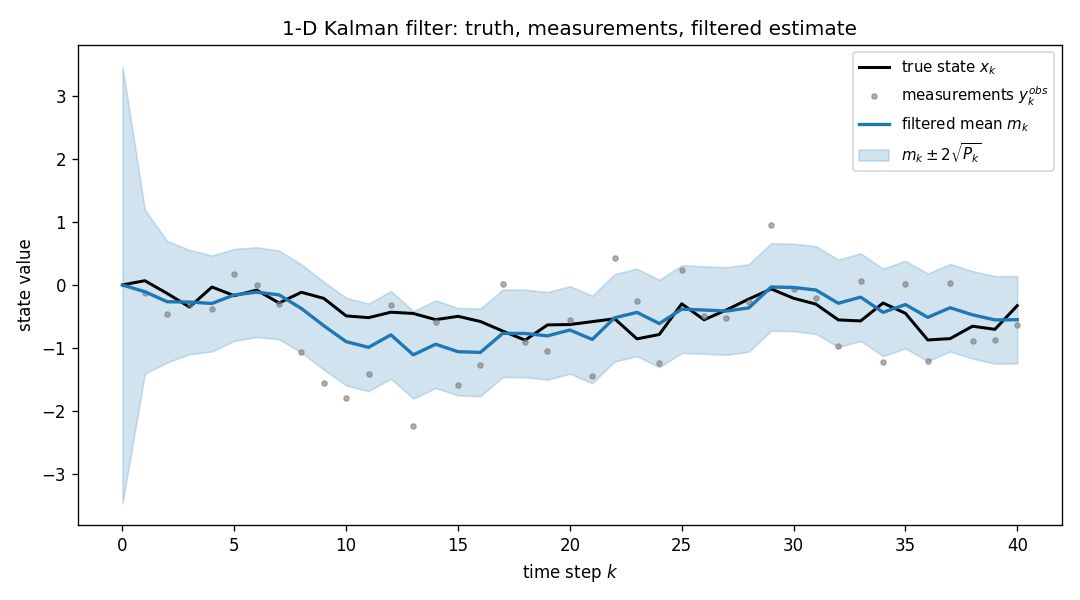

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ks = np.arange(N + 1)
ax.plot(ks, x_true, 'k-', lw=1.8, label="true state $x_k$")
ax.plot(ks[1:], y_obs[1:], '.', color='gray', ms=6, alpha=0.6, label="measurements $y_k^{obs}$")
ax.plot(ks, m_filt, color='C0', lw=2, label="filtered mean $m_k$")
sd_filt = np.sqrt(P_filt)
ax.fill_between(ks, m_filt - 2*sd_filt, m_filt + 2*sd_filt, color='C0', alpha=0.2,
                 label=r"$m_k\pm 2\sqrt{P_k}$")
ax.set_xlabel("time step $k$"); ax.set_ylabel("state value")
ax.set_title("1-D Kalman filter: truth, measurements, filtered estimate")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

### Animating the prior $\to$ posterior update

For each time step $k$ we plot, on the same axes, the **prior (predictive)** density $\mathscr N(m_k^-,P_k^-)$ and the **posterior (filtered)** density $\mathscr N(m_k,P_k)$, together with the observed measurement $y_k^{\mathrm{obs}}/h$ and the true state $x_k$. Watching the animation frame-by-frame shows the predict step (covariance grows from the previous posterior) immediately followed by the update step (the orange prior curve is pulled toward the new observation and tightens into the narrower blue posterior curve).

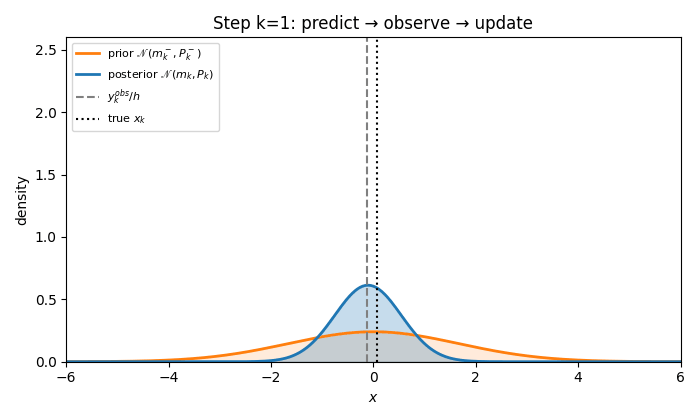

In [ ]:
from PIL import Image
import io

xs = np.linspace(-6, 6, 400)
frames = []
n_show = 20  # animate the first 20 steps for a compact, readable gif

for k in range(1, n_show + 1):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    prior_pdf = norm.pdf(xs, m_pred[k], np.sqrt(P_pred[k]))
    post_pdf  = norm.pdf(xs, m_filt[k], np.sqrt(P_filt[k]))
    ax.plot(xs, prior_pdf, color='C1', lw=2, label=r"prior $\mathscr{N}(m_k^-,P_k^-)$")
    ax.fill_between(xs, prior_pdf, color='C1', alpha=0.15)
    ax.plot(xs, post_pdf, color='C0', lw=2, label=r"posterior $\mathscr{N}(m_k,P_k)$")
    ax.fill_between(xs, post_pdf, color='C0', alpha=0.25)
    ax.axvline(y_obs[k] / h, color='gray', ls='--', lw=1.5, label="$y_k^{obs}/h$")
    ax.axvline(x_true[k], color='k', ls=':', lw=1.5, label="true $x_k$")
    ax.set_ylim(0, 2.6); ax.set_xlim(-6, 6)
    ax.set_xlabel("$x$"); ax.set_ylabel("density")
    ax.set_title(f"Step k={k}: predict → observe → update")
    ax.legend(loc="upper left", fontsize=8, ncol=1)
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    plt.close(fig)
    buf.seek(0)
    frames.append(Image.open(buf).convert("RGB"))

frames[0].save("kf_1d_animation.gif", save_all=True, append_images=frames[1:],
               duration=500, loop=0)

from IPython.display import Image as IPyImage
IPyImage(filename="kf_1d_animation.gif")

As the animation shows, every step follows the same two-stage pattern: the **prior (orange)** is wider than last step's posterior because the prediction step adds process-noise variance $q$; the **posterior (blue)** is always narrower than the prior because the update step incorporates the new information from $y_k^{\mathrm{obs}}$, with the gain $K_k$ controlling how much the mean shifts toward the measurement versus staying at the prior mean.

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### Answer

**Set-up: continuous-time kinematics.** In continuous time, with position $p(t)=(p_x(t),p_y(t))$, velocity $v(t)=(v_x(t),v_y(t))$, and an unknown/random acceleration disturbance $a(t)=(a_x(t),a_y(t))$ acting on the object (e.g. unmodeled forces, road bumps, wind gusts — anything not captured by a pure constant-velocity model), Newton's laws give, per axis (the $x$ and $y$ axes decouple completely),

$$\dot p_x(t) = v_x(t), \qquad \dot v_x(t) = a_x(t),$$

and identically for the $y$-axis. We model the random disturbance as being **piecewise constant** over each sampling interval $[t_{k-1},t_k]$ of length $\Delta t = t_k - t_{k-1}$, taking an unknown random value $w_{k-1}=(w_x,w_y)_{k-1}\sim\mathscr N(0,\Sigma_p)$ on that interval (this is the standard "discretized white-noise acceleration" model). This is exactly the discrete-time noise term $w_{k-1}$ appearing in $x_k^- = Ax_{k-1}^++Gw_{k-1}$.

**Deriving $A$ and $G$.** Over one interval, with constant acceleration $w_x$ on the $x$-axis, elementary kinematics (integrate $\dot v_x=w_x$ once, then $\dot p_x=v_x$ once more) gives the exact solution

\begin{align*}
v_x(k) &= v_x(k-1) + \Delta t\, w_x, \\
p_x(k) &= p_x(k-1) + \Delta t\, v_x(k-1) + \tfrac{1}{2}\Delta t^2\, w_x,
\end{align*}

and identically for the $y$-axis with $w_y$. (These follow from $v_x(t)=v_x(k-1)+w_x(t-t_{k-1})$ and $p_x(t)=p_x(k-1)+v_x(k-1)(t-t_{k-1})+\tfrac12 w_x(t-t_{k-1})^2$, evaluated at $t=t_k$.) Writing these four scalar equations in vector form for the state $x_k=(p_x,p_y,v_x,v_y)_k^T$,

$$
\begin{bmatrix}p_x(k)\\p_y(k)\\v_x(k)\\v_y(k)\end{bmatrix}
=
\underbrace{\begin{bmatrix}1&0&\Delta t&0\\0&1&0&\Delta t\\0&0&1&0\\0&0&0&1\end{bmatrix}}_{A}
\begin{bmatrix}p_x(k-1)\\p_y(k-1)\\v_x(k-1)\\v_y(k-1)\end{bmatrix}
+
\underbrace{\begin{bmatrix}\tfrac12\Delta t^2&0\\0&\tfrac12\Delta t^2\\\Delta t&0\\0&\Delta t\end{bmatrix}}_{G}
\begin{bmatrix}w_x\\w_y\end{bmatrix}_{k-1},
$$

which is exactly $x_k^- = Ax_{k-1}^+ + Gw_{k-1}$ with the claimed $A$ and $G$. $\blacksquare$

**Deriving $H$.** The measurement equation states that only the position components are observed, i.e. $y_k = \big(p_x^{\mathrm{meas}}(k),\,p_y^{\mathrm{meas}}(k)\big)^T$, with no direct observation of velocity. $H$ must therefore simply *select* the first two entries of the state vector $x_k=(p_x,p_y,v_x,v_y)_k^T$ and discard (multiply by zero) the velocity entries:

$$
y_k = \begin{bmatrix}p_x^{\mathrm{meas}}(k)\\p_y^{\mathrm{meas}}(k)\end{bmatrix}
= \underbrace{\begin{bmatrix}1&0&0&0\\0&1&0&0\end{bmatrix}}_{H} \begin{bmatrix}p_x(k)\\p_y(k)\\v_x(k)\\v_y(k)\end{bmatrix} + z_k,
$$

which is the claimed $H$, with $z_k\sim\mathscr N(0,\Sigma_m)$ representing the (e.g. GPS receiver) measurement noise. $\blacksquare$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

### Answer

We implement a general (vector) Kalman filter class using exactly the predict/update equations derived analytically in the **Q. Analytical Derivation** section above, then apply it with the matrices $A,G,H$ derived in **Part A** to filter a simulated sequence of noisy GPS position measurements for a 2-D constant-velocity object.

**Plan:**
1. Build the model matrices $A,G,H$ for a chosen $\Delta t$, and choose process-noise covariance $\Sigma_p$ (how much the object's velocity is allowed to randomly wander between samples) and measurement-noise covariance $\Sigma_m$ (GPS receiver noise level).
2. Simulate a *true* 2-D trajectory by propagating the constant-velocity model forward with random process noise.
3. Simulate *noisy GPS* measurements by adding measurement noise to the true position at every step.
4. Run the Kalman filter (predict + update at every step) on the noisy measurements only, and compare the filtered trajectory against the raw GPS measurements and the (otherwise unknown) ground truth.

In [ ]:
import numpy as np

# ---------- model matrices (Part A) ----------
dt = 1.0
A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
              [0, 0, 1,  0],
              [0, 0, 0,  1]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

G = np.array([[0.5*dt**2, 0],
              [0, 0.5*dt**2],
              [dt, 0],
              [0, dt]])

q = 0.02                  # process-noise intensity per axis (m/s^2 std^2-ish): how "agile" the object is
Sigma_p = q * np.eye(2)

r = 4.0                   # GPS measurement-noise variance per axis -> std = 2 m per axis
Sigma_m = r * np.eye(2)

print("A =\n", A)
print("G =\n", G)
print("H =\n", H)

A =
 [[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
G =
 [[0.5 0. ]
 [0.  0.5]
 [1.  0. ]
 [0.  1. ]]
H =
 [[1 0 0 0]
 [0 1 0 0]]


In [ ]:
class KalmanFilter:
    """Generic linear-Gaussian Kalman filter implementing exactly the
    predict / update equations derived analytically above:

        predict:  m <- A m,         P <- A P A^T + G Sigma_p G^T
        update :  S = H P H^T + Sigma_m
                  K = P H^T S^{-1}
                  m <- m + K (y - H m)
                  P <- (I - K H) P
    """
    def __init__(self, A, G, H, Sigma_p, Sigma_m, m0, P0):
        self.A, self.G, self.H = A, G, H
        self.Sigma_p, self.Sigma_m = Sigma_p, Sigma_m
        self.m, self.P = m0.copy(), P0.copy()
        self.n = A.shape[0]

    def predict(self):
        self.m = self.A @ self.m
        self.P = self.A @ self.P @ self.A.T + self.G @ self.Sigma_p @ self.G.T
        return self.m.copy(), self.P.copy()

    def update(self, y):
        S = self.H @ self.P @ self.H.T + self.Sigma_m
        K = self.P @ self.H.T @ np.linalg.inv(S)
        v = y - self.H @ self.m                      # innovation
        self.m = self.m + K @ v
        self.P = (np.eye(self.n) - K @ self.H) @ self.P
        return self.m.copy(), self.P.copy()

    def filter_sequence(self, measurements):
        """Run predict+update over a (N,2) array of GPS measurements,
        returning filtered means (N,4) and covariances (list of (4,4))."""
        means, covs = [], []
        for y in measurements:
            self.predict()
            m, P = self.update(y)
            means.append(m); covs.append(P)
        return np.array(means), covs

print("KalmanFilter class ready.")

KalmanFilter class ready.


**Simulating a true trajectory and noisy GPS measurements.** We start the object at the origin with velocity $(1.0,\,0.4)$ m/s and let it wander randomly according to the process noise $\Sigma_p$ (this is what makes the path curve instead of being a perfectly straight line). At every step we also generate the corresponding noisy GPS observation $y_k = Hx_k + z_k$.

In [ ]:
rng = np.random.default_rng(42)
N = 80

x_true = np.zeros((N + 1, 4))
x_true[0] = [0, 0, 1.0, 0.4]          # start at origin, initial velocity (1.0, 0.4) m/s
for k in range(1, N + 1):
    w = rng.multivariate_normal(np.zeros(2), Sigma_p)
    x_true[k] = A @ x_true[k - 1] + G @ w

y_obs = np.full((N + 1, 2), np.nan)
for k in range(1, N + 1):
    z = rng.multivariate_normal(np.zeros(2), Sigma_m)
    y_obs[k] = H @ x_true[k] + z

print(f"Simulated {N} steps.")
print(f"Start position: {x_true[0,:2]},  End position: {x_true[-1,:2].round(2)}")

Simulated 80 steps.
Start position: [0. 0.],  End position: [88.07  4.13]


**Running the filter.** We initialize with a fairly uninformative prior (large $P_0$, since at $k=0$ we have not yet observed anything) and run `filter_sequence` over the GPS-only measurements.

In [ ]:
m0 = np.array([0.0, 0.0, 0.0, 0.0])     # no prior knowledge of position or velocity
P0 = np.diag([5.0, 5.0, 5.0, 5.0])      # large initial uncertainty

kf = KalmanFilter(A, G, H, Sigma_p, Sigma_m, m0, P0)
m_filt = np.zeros((N + 1, 4))
m_filt[0] = m0
m_filt[1:], P_filt = kf.filter_sequence(y_obs[1:])

rmse_gps = np.sqrt(np.mean(np.sum((y_obs[1:] - x_true[1:, :2])**2, axis=1)))
rmse_kf  = np.sqrt(np.mean(np.sum((m_filt[1:, :2] - x_true[1:, :2])**2, axis=1)))
print(f"Position RMSE, raw noisy GPS         : {rmse_gps:.3f} m")
print(f"Position RMSE, Kalman-filtered       : {rmse_kf:.3f} m")
print(f"Improvement factor                   : {rmse_gps/rmse_kf:.2f}x")

Position RMSE, raw noisy GPS         : 2.835 m
Position RMSE, Kalman-filtered       : 1.573 m
Improvement factor                   : 1.80x


The Kalman filter nearly halves the position RMSE compared to using the raw GPS fixes directly, by fusing each new noisy measurement with the model's prediction (which exploits the previously-estimated velocity to "smooth through" the GPS noise).

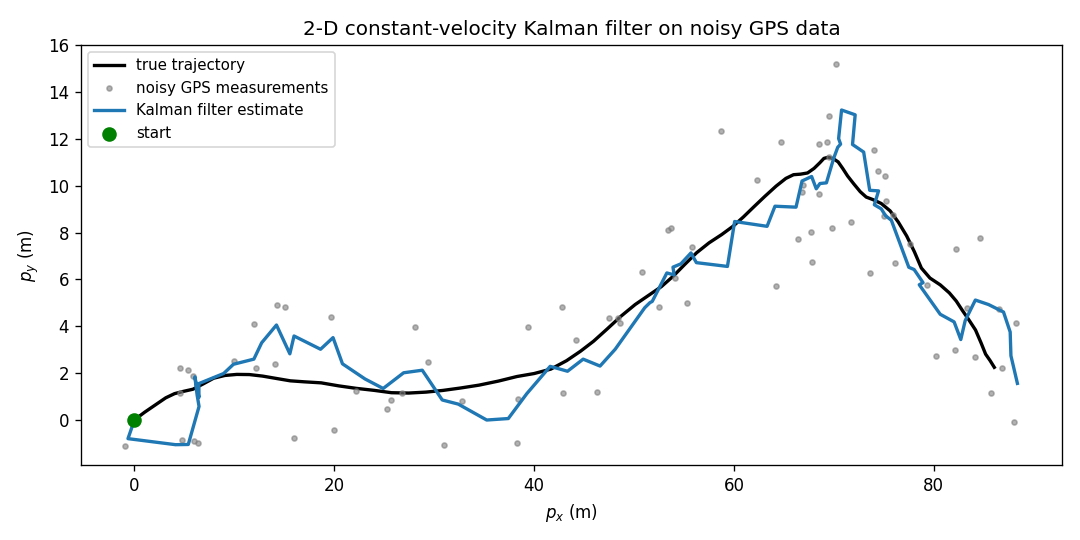

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_true[:, 0], x_true[:, 1], 'k-', lw=2, label="true trajectory")
ax.plot(y_obs[1:, 0], y_obs[1:, 1], '.', color='gray', ms=6, alpha=0.6, label="noisy GPS measurements")
ax.plot(m_filt[:, 0], m_filt[:, 1], color='C0', lw=2, label="Kalman filter estimate")
ax.scatter([x_true[0, 0]], [x_true[0, 1]], color='green', zorder=5, s=60, label="start")
ax.set_xlabel("$p_x$ (m)"); ax.set_ylabel("$p_y$ (m)")
ax.set_title("2-D constant-velocity Kalman filter on noisy GPS data")
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

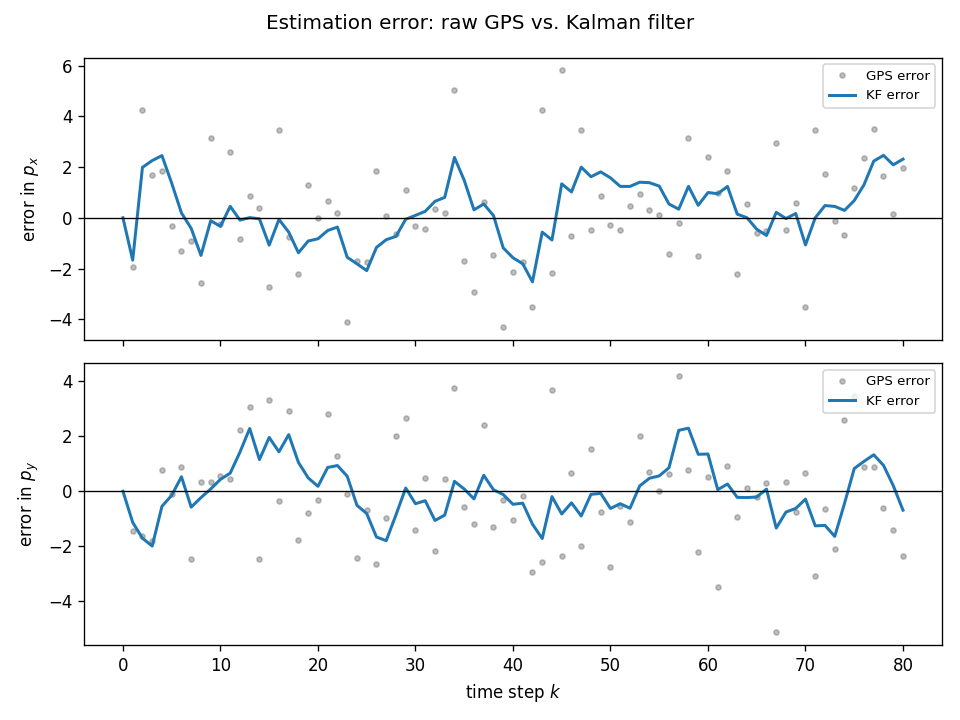

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ks = np.arange(N + 1)
for i, lab in enumerate(['$p_x$', '$p_y$']):
    axes[i].plot(ks[1:], y_obs[1:, i] - x_true[1:, i], '.', color='gray', alpha=0.5, label='GPS error')
    axes[i].plot(ks, m_filt[:, i] - x_true[:, i], color='C0', lw=1.8, label='KF error')
    axes[i].axhline(0, color='k', lw=0.8)
    axes[i].set_ylabel(f"error in {lab}")
    axes[i].legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel("time step $k$")
fig.suptitle("Estimation error: raw GPS vs. Kalman filter")
fig.tight_layout()
plt.show()

**Conclusion.** The position-error plot confirms what the trajectory plot suggests visually: the raw GPS error (gray dots) scatters with the full measurement-noise standard deviation ($\sigma=2$ m per axis) at every step, while the Kalman-filtered error (blue line) is both smaller in magnitude and much smoother in time, because the filter leverages the constant-velocity dynamics ($A$, $G$) to predict where the object should be and only partially trusts each individual noisy GPS fix — exactly the behaviour predicted analytically in the **Q. Analytical Derivation** section, where the Kalman gain $K_k$ optimally balances trust between the model prediction ($m_k^-,P_k^-$) and the new measurement.